# IM 混合贡献季节因子的窗口比较

本 Notebook 比较 30、60、120、360 个交易日窗口下的混合贡献季节因子及事后诊断。
符号与[项目符号与方法说明](../volatility_research/README.md)
及[估计 Notebook](02_01_im_bpv_intraday_seasonality.ipynb)一致。

收益及其周期尺度沿用 Boudt 等收益过滤文献的符号约定：$r$ 表示收益，
$f$ 表示标准差周期，$f^2$ 表示方差周期。其他文献须按定义映射。
本页使用的 $c$、$x$、$g$、$z$ 是为混合贡献实验明确约定的项目记号。

| 符号 | 含义 | 代码对应或用途 |
|---|---|---|
| $t$；$i=1,\ldots,M$；$L$ | 交易日；全天分钟位置，$M=240$；回望交易日数 | 09:31 为 $i=1$，13:01 为 $i=121$ |
| $c^{\mathrm{mix}}_{t,i}$ | 首分钟收益平方、其余分钟 BV 求和项构成的混合贡献 | `variance_contribution_matrix` |
| $x^{\mathrm{mix}}_{t,i}$ | 原始混合贡献除以当日平均混合贡献 | 原始序列的日内相对形状 |
| $\widehat g^{\mathrm{mix},(L)}_{t,i}$ | 历史相对混合贡献逐分钟取中位数、再归一化得到的季节因子 | `seasonality_by_lookback[L]` |
| $c^{\mathrm{mix,adj},(L)}_{t,i}$ | $c^{\mathrm{mix}}_{t,i}/\widehat g^{\mathrm{mix},(L)}_{t,i}$ | `variance_adjusted_by_lookback[L]` |
| $z^{\mathrm{mix},(L)}_{t,i}$ | 调整后混合贡献除以其当日分钟均值 | 事后分布诊断；代码 `z_values` |
| $z^{\mathrm{mix},(L)}_{t,i}-1$ | 相对于当日均值的偏离 | `residual_by_lookback[L]`，图中称“相对残差” |

$\widehat g^{\mathrm{mix},(L)}$ 是贡献因子，不能仅由构造认定为收益方差周期 $f^2$。
$z^{\mathrm{mix},(L)}$ 使用目标日完整实现值，是事后诊断变量；图中的“相对残差”也不是收益模型的创新项。

#### Cell 1：路径、参数和绘图设置。

In [35]:
import pathlib
import sys
import datetime as dt

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

research_dir = (
    candidate_root / "01_project_collection/JQ_strategy/draft_experiments_v2"
)
lookback_windows = (30, 60, 120, 360)
window_colors = {
    30: "#147D92", 60: "#D08022",
    120: "#7357A5", 360: "#BD4358",
}

lunch_gap_slots = 10  # 可改为 10、20、30，控制午休显示宽度
plot_minute_positions = np.r_[
    np.arange(120),
    np.arange(120, 240) + lunch_gap_slots,
]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Microsoft YaHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

#### Cell 2：读取四份结果，整理原始混合贡献 $c^{\mathrm{mix}}$、季节因子 $\widehat g^{\mathrm{mix},(L)}$ 和调整后混合贡献 $c^{\mathrm{mix,adj},(L)}$ 矩阵。

In [16]:
input_schema = pa.schema([
    pa.field("trading_date", pa.date32(), nullable=False),
    pa.field("minute_slot", pa.time64("us"), nullable=False),
    pa.field("variance_contribution", pa.float64()),
    pa.field("variance_seasonality", pa.float64()),
    pa.field("variance_adjusted", pa.float64()),
])

output_by_lookback = {}
seasonality_by_lookback = {}
variance_adjusted_by_lookback = {}

for lookback in lookback_windows:
    source_path = (
        research_dir / f"im_bpv_seasonality_1m_{lookback}td.parquet"
    )
    output_table = pq.read_table(source_path, columns=input_schema.names)
    output_df = (
        output_table.cast(input_schema)
        .to_pandas(types_mapper=pd.ArrowDtype)
        .set_index(["trading_date", "minute_slot"])
        .sort_index()
    )

    output_by_lookback[lookback] = output_df
    seasonality_by_lookback[lookback] = (
        output_df["variance_seasonality"]
        .unstack("minute_slot")
        .astype("float64")
    )
    variance_adjusted_by_lookback[lookback] = (
        output_df["variance_adjusted"]
        .unstack("minute_slot")
        .astype("float64")
    )

reference_output_df = output_by_lookback[lookback_windows[0]]
variance_contribution_matrix = (
    reference_output_df["variance_contribution"]
    .unstack("minute_slot")
    .astype("float64")
)

trading_dates = variance_contribution_matrix.index
minute_slots = variance_contribution_matrix.columns

#### Cell 3：取共同有效样本，使四个窗口使用相同交易日比较。

In [17]:
common_day_mask = (
    np.isfinite(variance_contribution_matrix).all(axis=1)
    & variance_contribution_matrix.sum(axis=1).gt(0)
)

for lookback in lookback_windows:
    seasonality_matrix = seasonality_by_lookback[lookback]
    common_day_mask &= (
        np.isfinite(seasonality_matrix).all(axis=1)
        & seasonality_matrix.gt(0).all(axis=1)
        & np.isfinite(
            variance_adjusted_by_lookback[lookback]
        ).all(axis=1)
    )

comparison_dates = trading_dates[common_day_mask]
plot_date = comparison_dates[-1]

# 保留区间内的缺失日期位置，后续绘图在这些位置断开。
visible_dates = trading_dates[
    (trading_dates >= comparison_dates[0])
    & (trading_dates <= comparison_dates[-1])
]

print(
    f"共同样本：{len(comparison_dates)} 个交易日"
    f" × {len(minute_slots)} 个分钟位置"
)

共同样本：635 个交易日 × 240 个分钟位置


#### Cell 4：比较同一天四个窗口的混合贡献季节因子 $\widehat g^{\mathrm{mix},(L)}$，上午、下午分开展示。

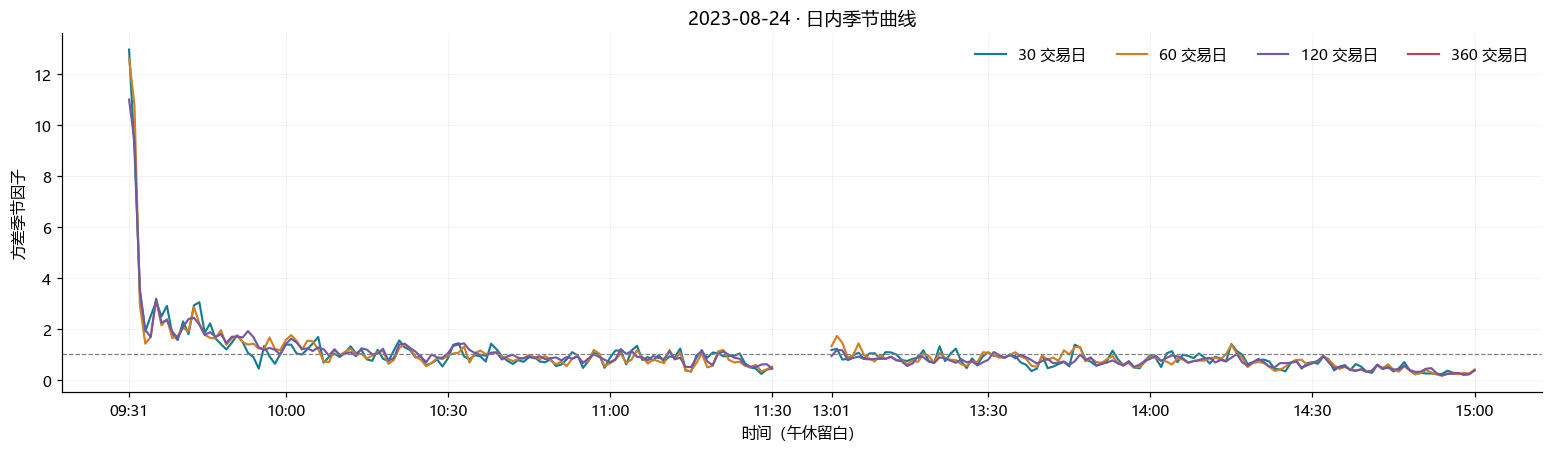

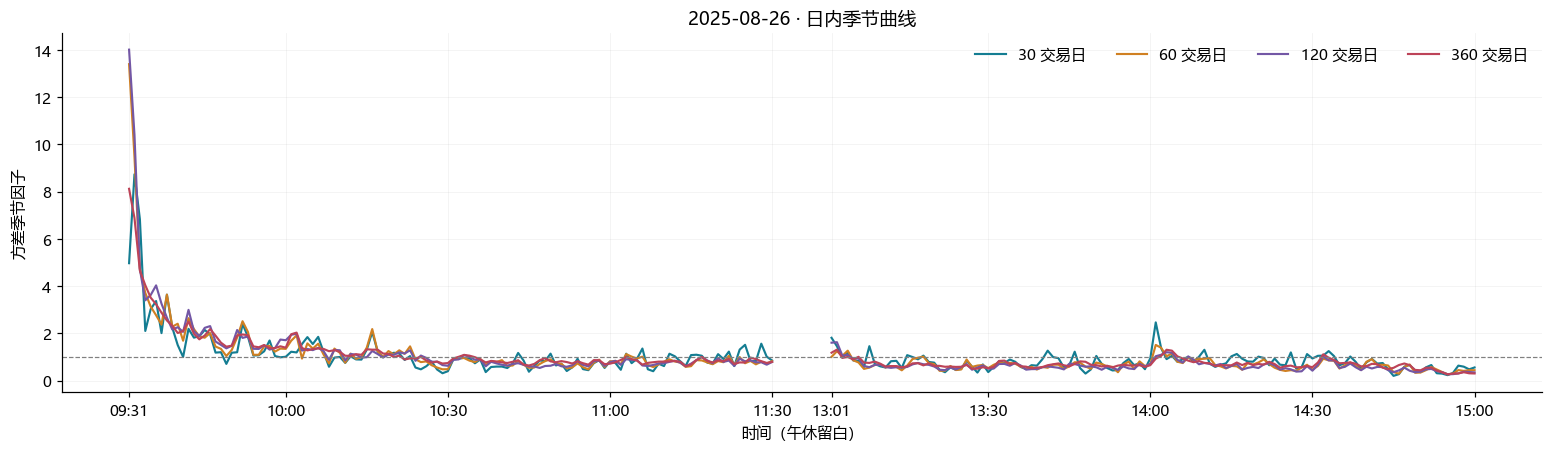

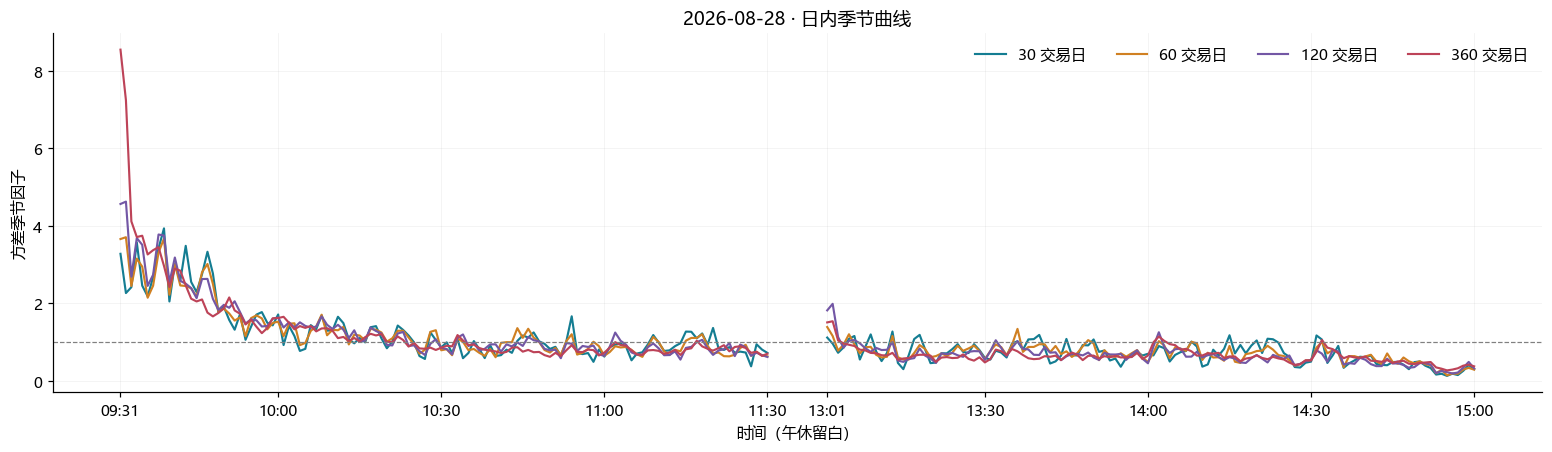

In [36]:
selected_dates = [
    "2023-08-24",
    "2025-08-26",
    "2026-08-28",
]

slot_positions = plot_minute_positions
tick_positions = [0, 29, 59, 89, 119, 120, 149, 179, 209, 239]

for date_text in selected_dates:
    selected_date = pd.Timestamp(date_text).date()
    figure, axis = plt.subplots(
        figsize=(14, 4), layout="constrained"
    )

    for lookback in lookback_windows:
        curve = seasonality_by_lookback[lookback].loc[
            selected_date
        ].to_numpy()

        for start, end in [(0, 120), (120, 240)]:
            axis.plot(
                slot_positions[start:end],
                curve[start:end],
                color=window_colors[lookback],
                linewidth=1.4,
                label=f"{lookback} 交易日" if start == 0 else None,
            )

    axis.set_xticks(
        slot_positions[tick_positions],
        [minute_slots[i].strftime("%H:%M") for i in tick_positions],
    )
    axis.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    axis.set_title(f"{selected_date} · 日内季节曲线")
    axis.set_xlabel("时间（午休留白）")
    axis.set_ylabel("方差季节因子")
    axis.legend(ncol=4, frameon=False)
    axis.grid(alpha=0.18)
    plt.show()
    plt.close(figure)

#### Cell 5：绘制指定分钟的混合贡献季节因子 $\widehat g^{\mathrm{mix},(L)}$ 随日期变化。

每个分钟一幅子图，颜色只区分回望窗口。

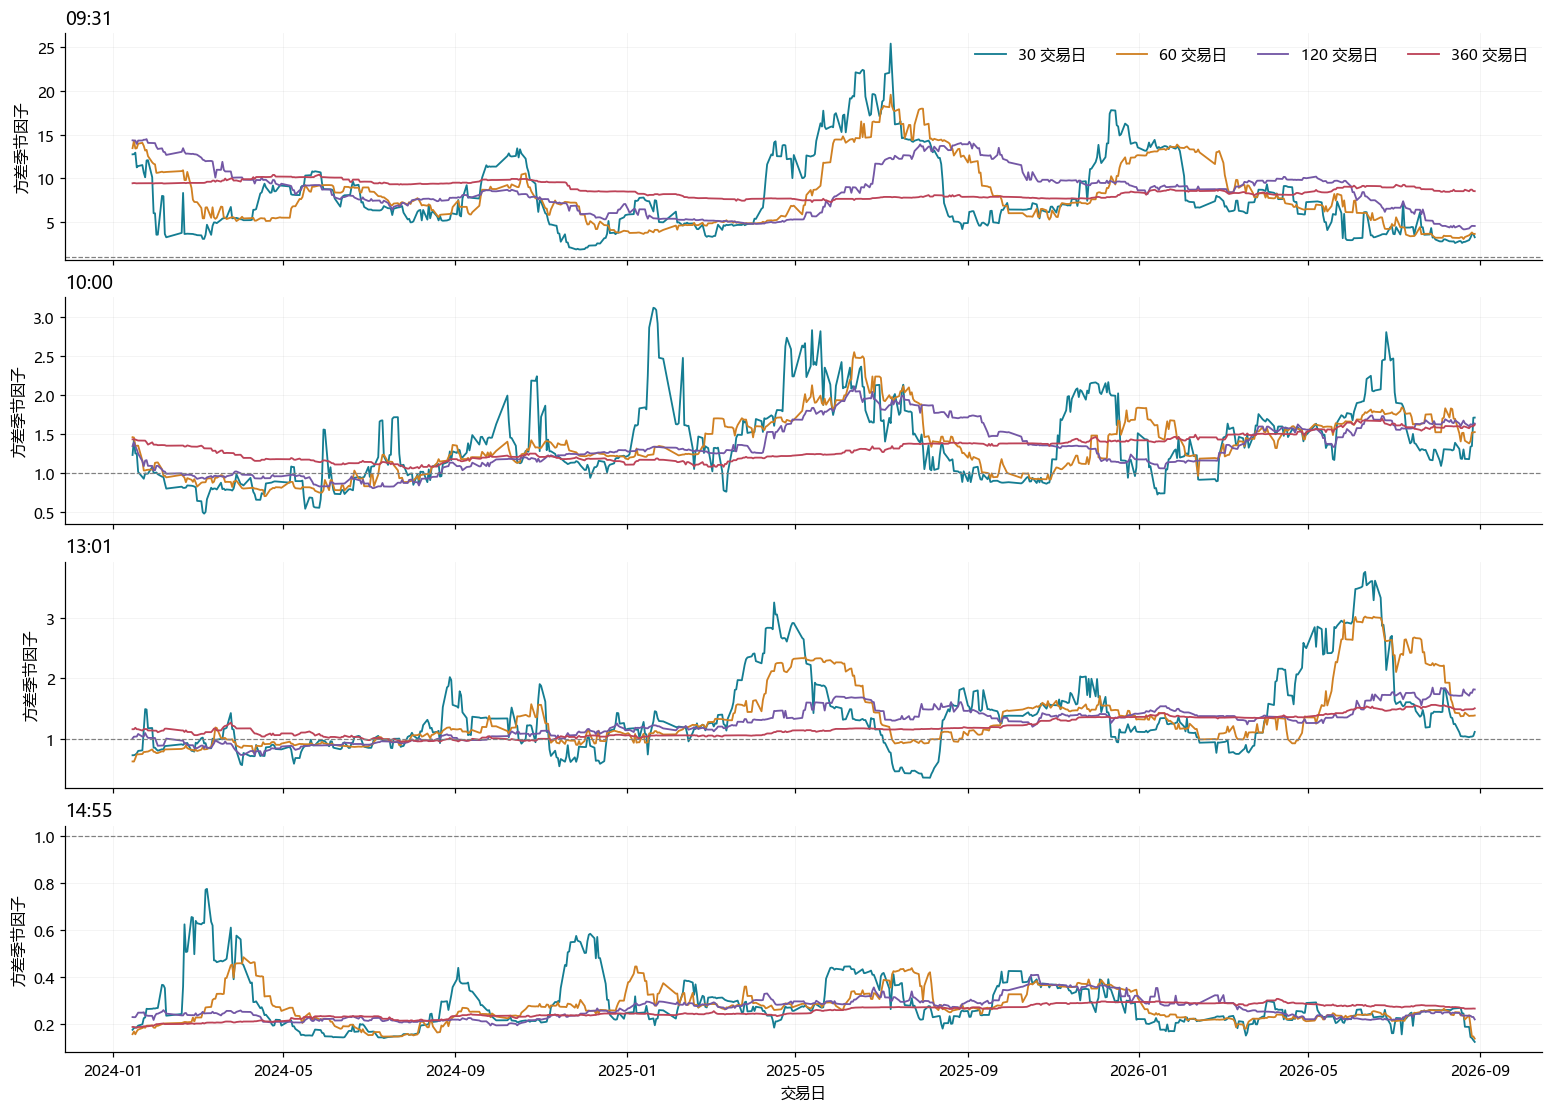

In [24]:
tracked_slots = [
    dt.time(9, 31),   # 09:31
    dt.time(10, 0),   # 10:00
    dt.time(13, 1),   # 13:01
    dt.time(14, 55),  # 14:55
]

figure, axes = plt.subplots(
    len(tracked_slots), 1,
    figsize=(14, 2.5 * len(tracked_slots)),
    sharex=True,
    layout="constrained",
)
axes = np.atleast_1d(axes)
plot_dates = pd.to_datetime(visible_dates)

for axis, minute_slot in zip(axes, tracked_slots):
    for lookback in lookback_windows:
        factor_series = seasonality_by_lookback[lookback].loc[
            visible_dates, minute_slot
        ].where(common_day_mask.loc[visible_dates])

        axis.plot(
            plot_dates,
            factor_series.to_numpy(),
            color=window_colors[lookback],
            linewidth=1.2,
            label=f"{lookback} 交易日",
        )

    axis.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    axis.set_title(minute_slot.strftime("%H:%M"), loc="left")
    axis.set_ylabel("方差季节因子")
    axis.grid(alpha=0.18)

axes[0].legend(ncol=4, frameon=False)
axes[-1].set_xlabel("交易日")
plt.show()
plt.close(figure)

#### Cell 6：准备时间网格和统一色标。
色标取共同样本的 1%—99% 分位，仅影响显示。

In [25]:
heatmap_slots = pd.Index(
    pd.date_range("2000-01-01 09:31", "2000-01-01 15:00", freq="min").time,
    name="minute_slot",
)

heatmap_values = np.concatenate([
    seasonality_by_lookback[lookback]
    .loc[comparison_dates].to_numpy().ravel()
    for lookback in lookback_windows
])

color_lower, color_upper = np.quantile(heatmap_values, [0.01, 0.99])
color_norm = LogNorm(vmin=color_lower, vmax=color_upper, clip=True)
color_map = plt.get_cmap("viridis").copy()
color_map.set_bad("#ECEEF1")

#### Cell 7：绘制四幅热力图，共用色标。横轴是分钟，纵轴是等距交易日。

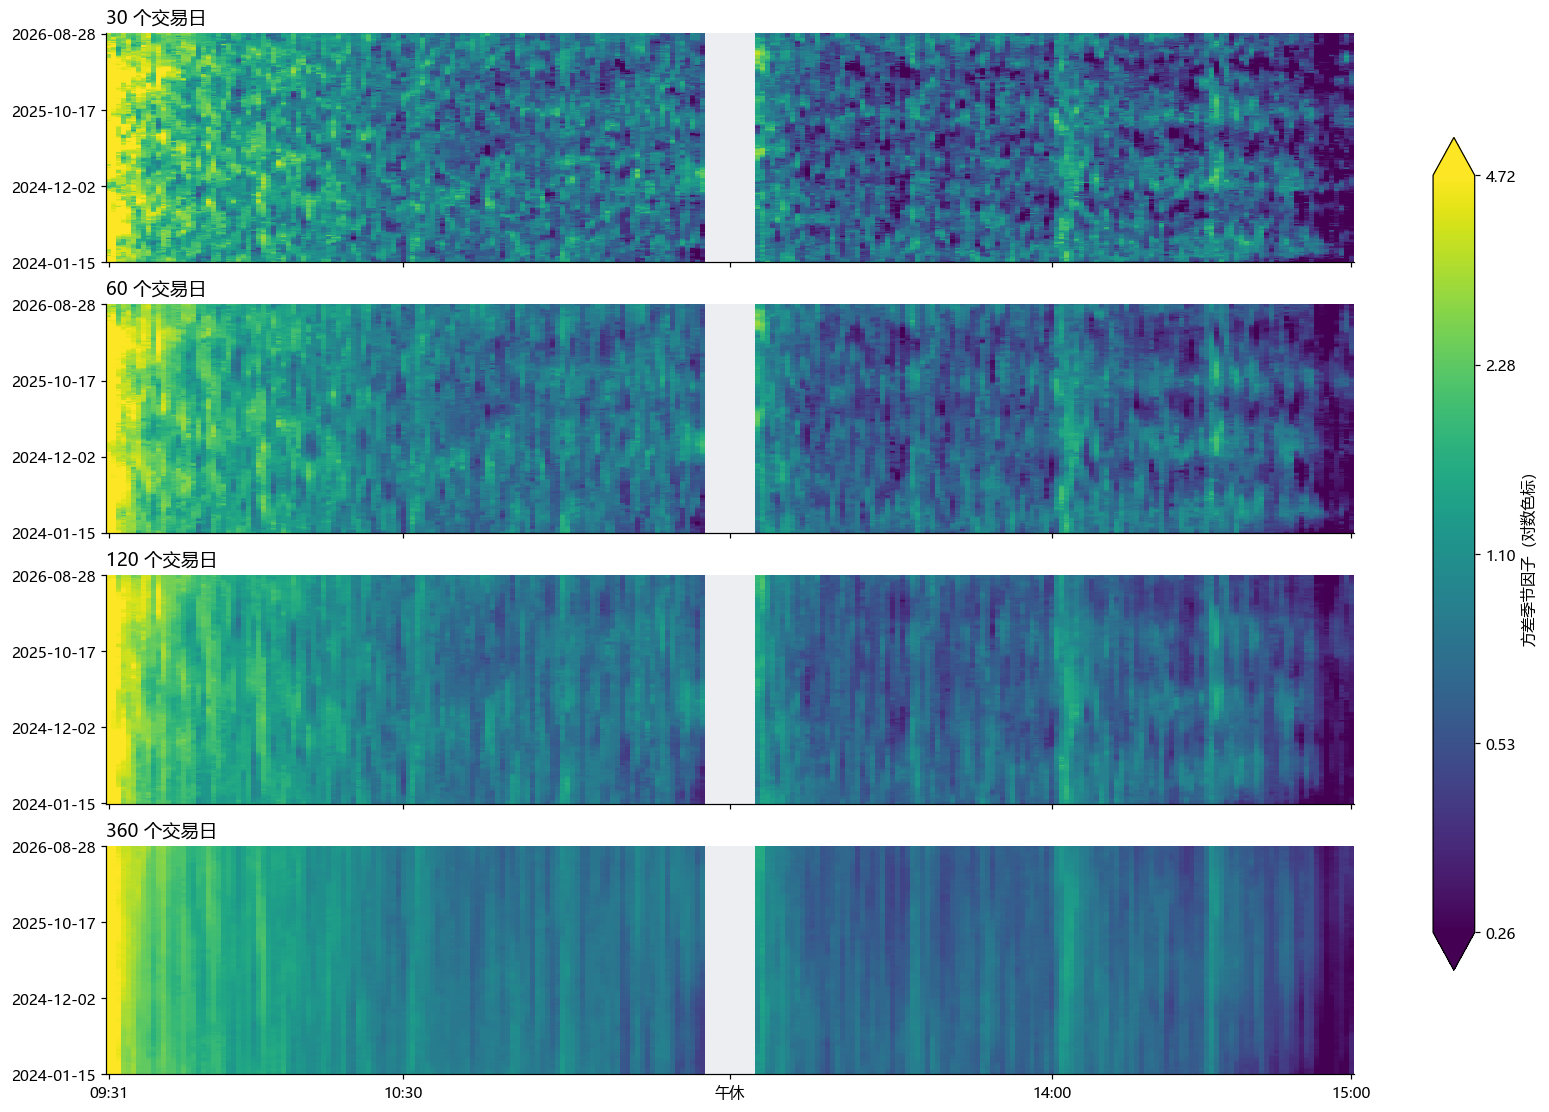

共同色标范围：0.256 至 4.717；其外数值仅在显示上饱和


In [38]:
heatmap_values = np.concatenate([
    seasonality_by_lookback[lookback]
    .loc[comparison_dates, minute_slots].to_numpy().ravel()
    for lookback in lookback_windows
])

color_lower, color_upper = np.quantile(heatmap_values, [0.01, 0.99])
if color_upper <= color_lower:
    color_upper = color_lower * 1.01

color_norm = LogNorm(vmin=color_lower, vmax=color_upper)
color_map = plt.get_cmap("viridis").copy()
color_map.set_bad("#ECEEF1")

figure, axes = plt.subplots(
    len(lookback_windows), 1,
    figsize=(14, 10),
    sharex=True,
    layout="constrained",
)

for axis, lookback in zip(axes, lookback_windows):
    heatmap_matrix = (
        seasonality_by_lookback[lookback]
        .loc[visible_dates, minute_slots]
        .where(common_day_mask.loc[visible_dates], axis=0)
        .set_axis(plot_minute_positions, axis=1)
        .reindex(columns=np.arange(240 + lunch_gap_slots))
    )

    heatmap_image = axis.imshow(
        heatmap_matrix.to_numpy(),
        aspect="auto",
        origin="lower",
        cmap=color_map,
        norm=color_norm,
        interpolation="nearest",
    )

    # axis.axvline(
    #     119.5 + lunch_gap_slots / 2,
    #     color="white", linestyle="--", linewidth=1,
    # )

    date_ticks = np.linspace(0, len(visible_dates) - 1, 4, dtype=int)
    axis.set_yticks(
        date_ticks,
        [str(visible_dates[i]) for i in date_ticks],
    )
    axis.set_title(f"{lookback} 个交易日", loc="left")

slot_ticks = [
    0,
    59,
    119.5 + lunch_gap_slots / 2,
    179 + lunch_gap_slots,
    239 + lunch_gap_slots,
]

axes[-1].set_xticks(
    slot_ticks, ["09:31", "10:30", "午休", "14:00", "15:00"]
)

colorbar = figure.colorbar(
    heatmap_image,
    ax=axes,
    label="方差季节因子（对数色标）",
    extend="both",
    shrink=0.8,
)
color_ticks = np.geomspace(color_lower, color_upper, 5)
colorbar.set_ticks(
    color_ticks,
    labels=[f"{value:.2f}" for value in color_ticks],
)
colorbar.minorticks_off()

plt.show()
plt.close(figure)

print(
    f"共同色标范围：{color_lower:.3f} 至 {color_upper:.3f}；"
    "其外数值仅在显示上饱和"
)

#### Cell 8：各序列先按日均值归一化，再逐分钟取跨日均值，最后将曲线均值归一到 1。

当前执行代码使用 `mean(axis=0)`；中位数方案仅保留在注释中。
原始序列归一化后是 $x^{\mathrm{mix}}_{t,i}$，
调整后序列归一化后是：

$$
z^{\mathrm{mix},(L)}_{t,i}
=
\frac{c^{\mathrm{mix,adj},(L)}_{t,i}}
     {M^{-1}\sum_{j=1}^{M}c^{\mathrm{mix,adj},(L)}_{t,j}}.
$$

这里的跨日均值用于评估残余形状，与估计季节因子时的历史中位数是不同步骤。
$z^{\mathrm{mix},(L)}$ 的分母使用目标日全日贡献，因此仅用于事后比较。

In [42]:
# 中位数
profile_inputs = {
    "原始": variance_contribution_matrix.loc[comparison_dates, minute_slots]
}
for lookback in lookback_windows:
    profile_inputs[f"{lookback} 交易日"] = (
        variance_adjusted_by_lookback[lookback]
        .loc[comparison_dates, minute_slots]
    )

profile_by_window = {}

for profile_name, contribution_matrix in profile_inputs.items():
    normalized_daily_matrix = contribution_matrix.div(
        contribution_matrix.mean(axis=1),
        axis=0,
    )

    # # 中位数 绘制
    # median_profile = normalized_daily_matrix.median(axis=0)
    # profile_by_window[profile_name] = median_profile / median_profile.mean()

    # 均值 绘制
    mean_profile = normalized_daily_matrix.mean(axis=0)
    profile_by_window[profile_name] = mean_profile / mean_profile.mean()

profile_df = pd.DataFrame(profile_by_window).reindex(minute_slots)

#### Cell 9：上图比较原始与调整后的跨日均值曲线，下图单独展示调整后曲线。

上午、下午分两段绘制。后续热力图和分布图使用
$z^{\mathrm{mix},(L)}_{t,i}-1$，以 0 表示当日平均水平；
最后的中位数、截尾均值、IQR 与 Q95 图使用 $z^{\mathrm{mix},(L)}_{t,i}$ 本身。
这些统计量检验不同分布特征，不要求都因同一乘法调整而同时变平。

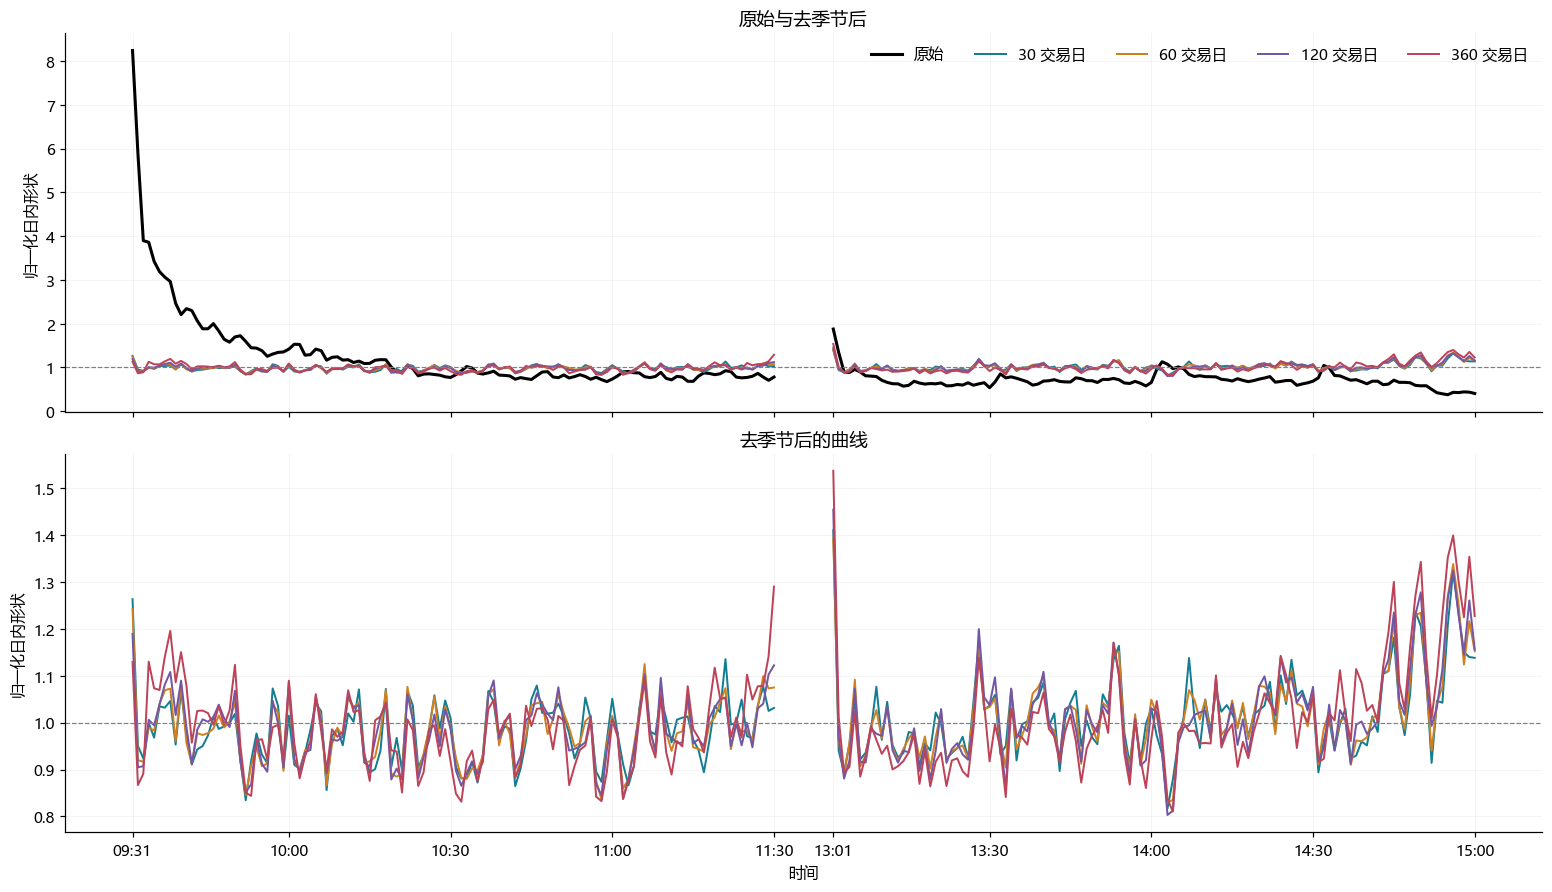

In [43]:
profile_slot_positions = plot_minute_positions
profile_tick_positions = [0, 29, 59, 89, 119, 120, 149, 179, 209, 239]

figure, axes = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    layout="constrained",
)

for start, end in [(0, 120), (120, 240)]:
    axes[0].plot(
        profile_slot_positions[start:end],
        profile_df["原始"].iloc[start:end].to_numpy(),
        color="black",
        linewidth=2,
        label="原始" if start == 0 else None,
    )

for axis in axes:
    for lookback in lookback_windows:
        profile_values = profile_df[f"{lookback} 交易日"].to_numpy()

        for start, end in [(0, 120), (120, 240)]:
            axis.plot(
                profile_slot_positions[start:end],
                profile_values[start:end],
                color=window_colors[lookback],
                linewidth=1.3,
                label=f"{lookback} 交易日" if start == 0 else None,
            )

    axis.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    axis.set_ylabel("归一化日内形状")
    axis.grid(alpha=0.18)

axes[0].set_title("原始与去季节后")
axes[0].legend(ncol=5, frameon=False)
axes[1].set_title("去季节后的曲线")
axes[1].set_xticks(
    profile_slot_positions[profile_tick_positions],
    [minute_slots[i].strftime("%H:%M") for i in profile_tick_positions],
)
axes[1].set_xlabel("时间")

plt.show()
plt.close(figure)

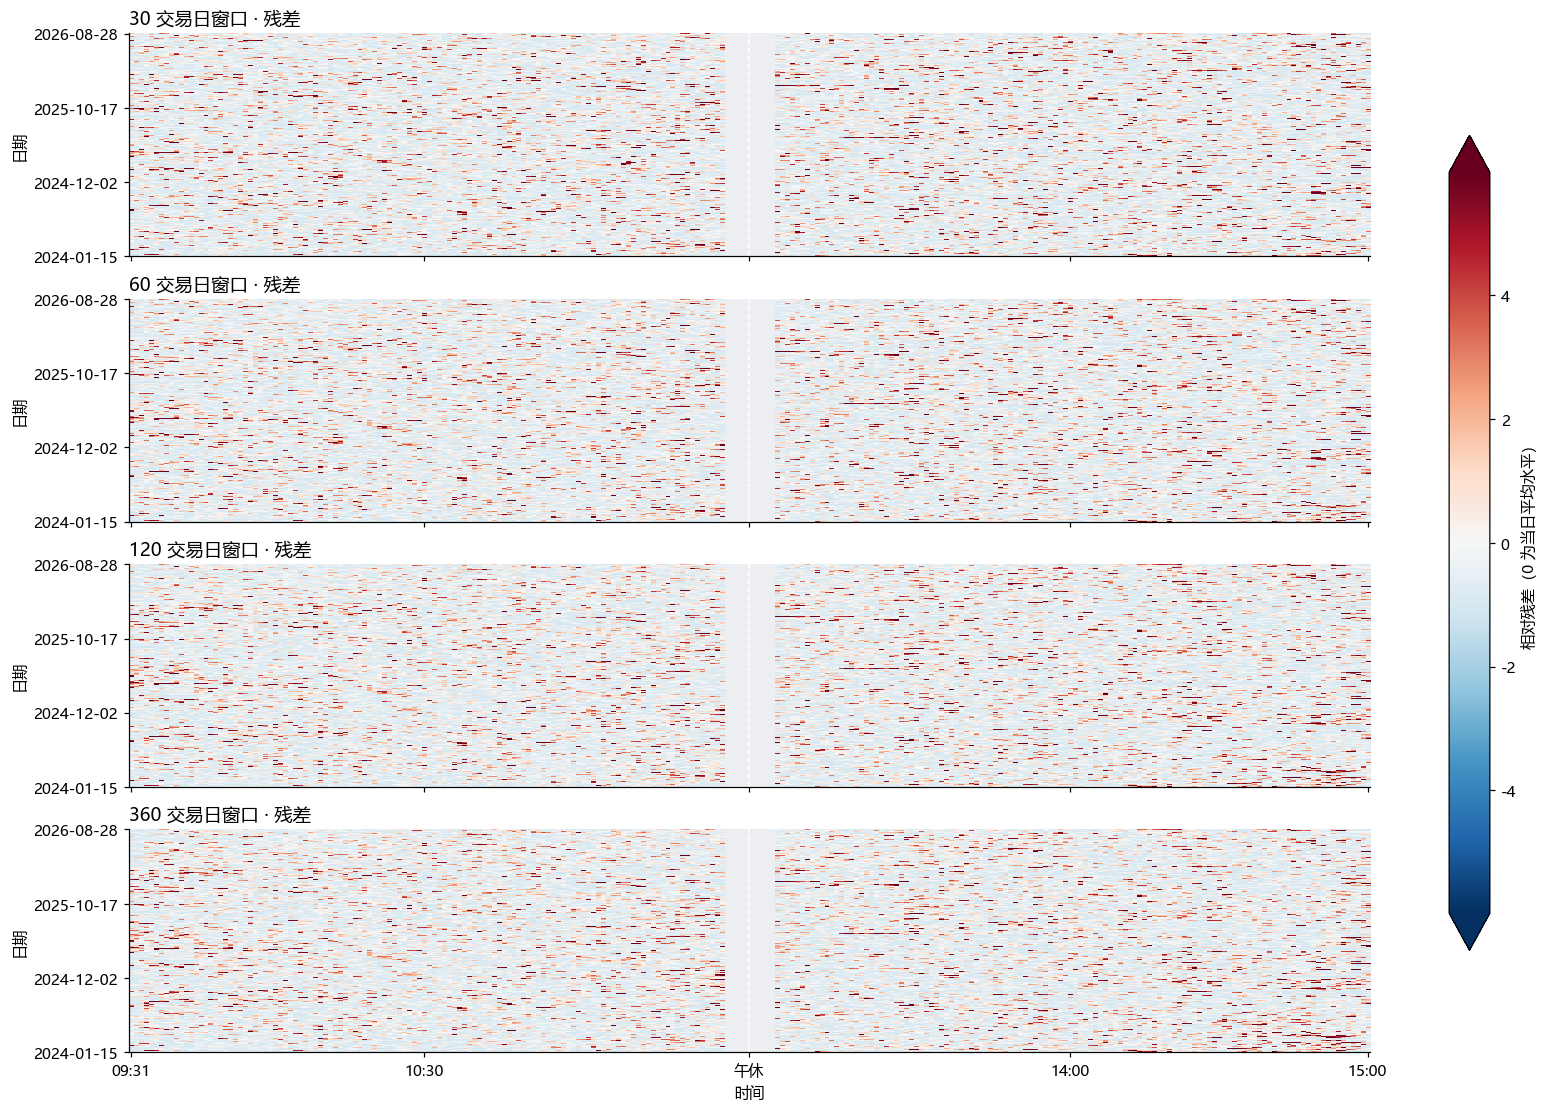

In [45]:
from matplotlib.colors import TwoSlopeNorm

residual_by_lookback = {}

for lookback in lookback_windows:
    adjusted_matrix = (
        variance_adjusted_by_lookback[lookback]
        .loc[visible_dates, minute_slots]
        .where(common_day_mask.loc[visible_dates], axis=0)
    )
    # 残差 = 去季节后的贡献 / 当日平均贡献 - 1
    residual_by_lookback[lookback] = adjusted_matrix.div(
        adjusted_matrix.mean(axis=1), axis=0
    ) - 1

residual_values = np.concatenate([
    residual_matrix.loc[comparison_dates].to_numpy().ravel()
    for residual_matrix in residual_by_lookback.values()
])
color_limit = max(np.nanquantile(np.abs(residual_values), 0.99), 1e-12)
residual_norm = TwoSlopeNorm(
    vmin=-color_limit, vcenter=0, vmax=color_limit
)
residual_cmap = plt.get_cmap("RdBu_r").copy()
residual_cmap.set_bad("#ECEEF1")

figure, axes = plt.subplots(
    len(lookback_windows), 1,
    figsize=(14, 10),
    sharex=True,
    squeeze=False,
    layout="constrained",
)
axes = axes.ravel()
date_ticks = np.linspace(0, len(visible_dates) - 1, 4, dtype=int)

for axis, lookback in zip(axes, lookback_windows):
    residual_display_matrix = (
        residual_by_lookback[lookback]
        .set_axis(plot_minute_positions, axis=1)
        .reindex(columns=np.arange(240 + lunch_gap_slots))
    )
    heatmap_image = axis.imshow(
        residual_display_matrix.to_numpy(),
        aspect="auto",
        origin="lower",
        cmap=residual_cmap,
        norm=residual_norm,
        interpolation="nearest",
    )
    axis.axvline(
        119.5 + lunch_gap_slots / 2,
        color="white", linestyle="--", linewidth=1,
    )
    axis.set_yticks(
        date_ticks,
        [str(visible_dates[i]) for i in date_ticks],
    )
    axis.set_ylabel("日期")
    axis.set_title(f"{lookback} 交易日窗口 · 残差", loc="left")

axes[-1].set_xticks(
    [
        0, 59, 119.5 + lunch_gap_slots / 2,
        179 + lunch_gap_slots, 239 + lunch_gap_slots,
    ],
    ["09:31", "10:30", "午休", "14:00", "15:00"],
)
axes[-1].set_xlabel("时间")

figure.colorbar(
    heatmap_image,
    ax=axes,
    label="相对残差（0 为当日平均水平）",
    extend="both",
    shrink=0.8,
)
plt.show()
plt.close(figure)

#### Cell 10：计算跨日均值曲线相对 1 的偏离、相邻交易日 $\widehat g^{\mathrm{mix},(L)}$ 的变化，以及同日同分钟不同窗口因子的差异。

In [40]:
metrics_df = pd.DataFrame({
    "形状平均绝对偏离": {
        name: float((profile - 1).abs().mean())
        for name, profile in profile_by_window.items()
    }
})
metrics_df.index.name = "序列"
metrics_df["因子日际平均绝对变化"] = np.nan

paired_day_mask = (
    common_day_mask
    & common_day_mask.shift(1, fill_value=False)
)

for lookback in lookback_windows:
    daily_change = (
        seasonality_by_lookback[lookback]
        .diff().abs().mean(axis=1)
    )
    metrics_df.loc[
        f"{lookback} 交易日", "因子日际平均绝对变化"
    ] = daily_change.loc[paired_day_mask].mean()

window_distance_df = pd.DataFrame(
    index=lookback_windows,
    columns=lookback_windows,
    dtype="float64",
)

for first_lookback in lookback_windows:
    first_log_factors = np.log(
        seasonality_by_lookback[first_lookback]
        .loc[comparison_dates, minute_slots].to_numpy()
    )
    for second_lookback in lookback_windows:
        second_log_factors = np.log(
            seasonality_by_lookback[second_lookback]
            .loc[comparison_dates, minute_slots].to_numpy()
        )
        window_distance_df.loc[first_lookback, second_lookback] = (
            np.abs(first_log_factors - second_log_factors).mean()
        )

display(metrics_df.round(4))

,形状平均绝对偏离,因子日际平均绝对变化
序列,,
原始,0.4358,NaN
30 交易日,0.0269,0.0617
60 交易日,0.0276,0.0317
120 交易日,0.0302,0.0160
360 交易日,0.0505,0.0054


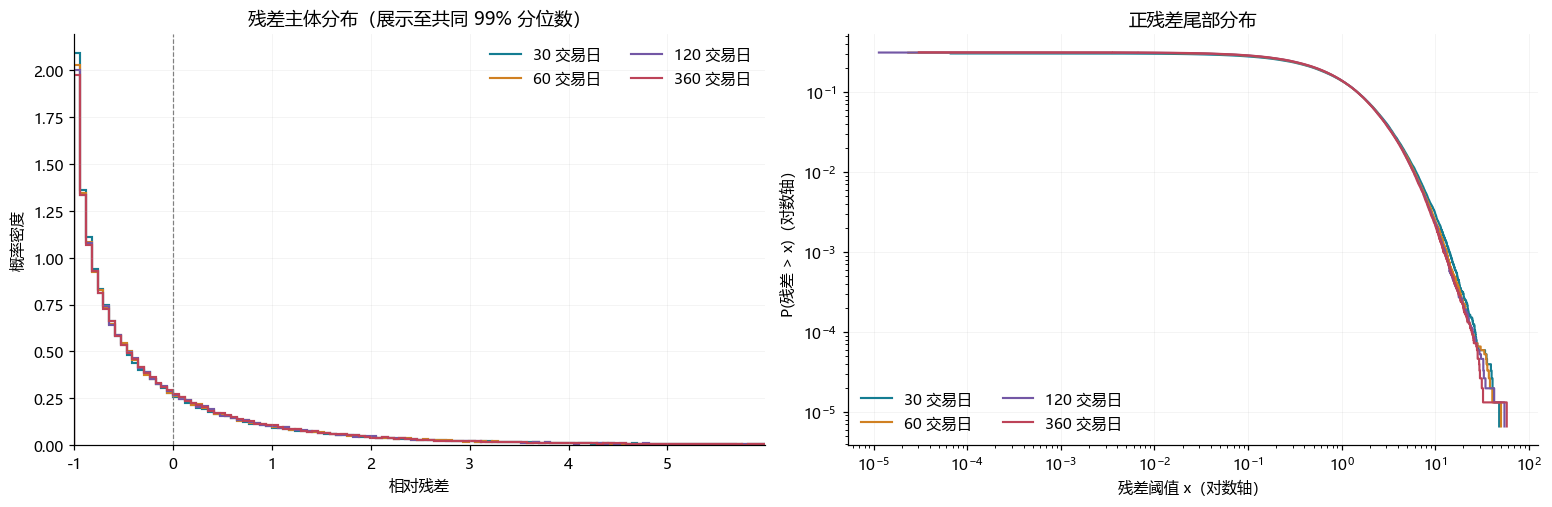

In [46]:
# 左图：主体分布；右图：正残差的尾部概率
distribution_by_lookback = {}

for lookback in lookback_windows:
    residual_values = (
        residual_by_lookback[lookback]
        .loc[comparison_dates, minute_slots]
        .to_numpy()
        .ravel()
    )
    distribution_by_lookback[lookback] = residual_values[
        np.isfinite(residual_values)
    ]

pooled_residual_values = np.concatenate(
    list(distribution_by_lookback.values())
)
distribution_upper = np.quantile(pooled_residual_values, 0.99)
distribution_bins = np.linspace(-1, distribution_upper, 120)

figure, axes = plt.subplots(
    1, 2, figsize=(14, 4.5), layout="constrained"
)

for lookback, residual_values in distribution_by_lookback.items():
    # 密度按全部样本计算，左图仅展示至共同的 99% 分位数
    bin_counts, bin_edges = np.histogram(
        residual_values, bins=distribution_bins
    )
    bin_density = bin_counts / (
        residual_values.size * np.diff(bin_edges)
    )
    axes[0].stairs(
        bin_density,
        bin_edges,
        color=window_colors[lookback],
        linewidth=1.4,
        label=f"{lookback} 交易日",
    )

    # 使用全部样本计算 P(残差 > x)
    residual_levels, level_counts = np.unique(
        residual_values, return_counts=True
    )
    tail_probability = (
        residual_values.size - np.cumsum(level_counts)
    ) / residual_values.size
    positive_tail_mask = (
        (residual_levels > 0) & (tail_probability > 0)
    )
    axes[1].step(
        residual_levels[positive_tail_mask],
        tail_probability[positive_tail_mask],
        where="post",
        color=window_colors[lookback],
        linewidth=1.4,
        label=f"{lookback} 交易日",
    )

axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlim(-1, distribution_upper)
axes[0].set_title("残差主体分布（展示至共同 99% 分位数）")
axes[0].set_xlabel("相对残差")
axes[0].set_ylabel("概率密度")

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("正残差尾部分布")
axes[1].set_xlabel("残差阈值 x（对数轴）")
axes[1].set_ylabel("P(残差 > x)（对数轴）")

for axis in axes:
    axis.grid(alpha=0.18)
    axis.legend(frameon=False, ncol=2)

plt.show()
plt.close(figure)

#### Cell 11：左图展示日际变化，右图展示窗口之间的差异。

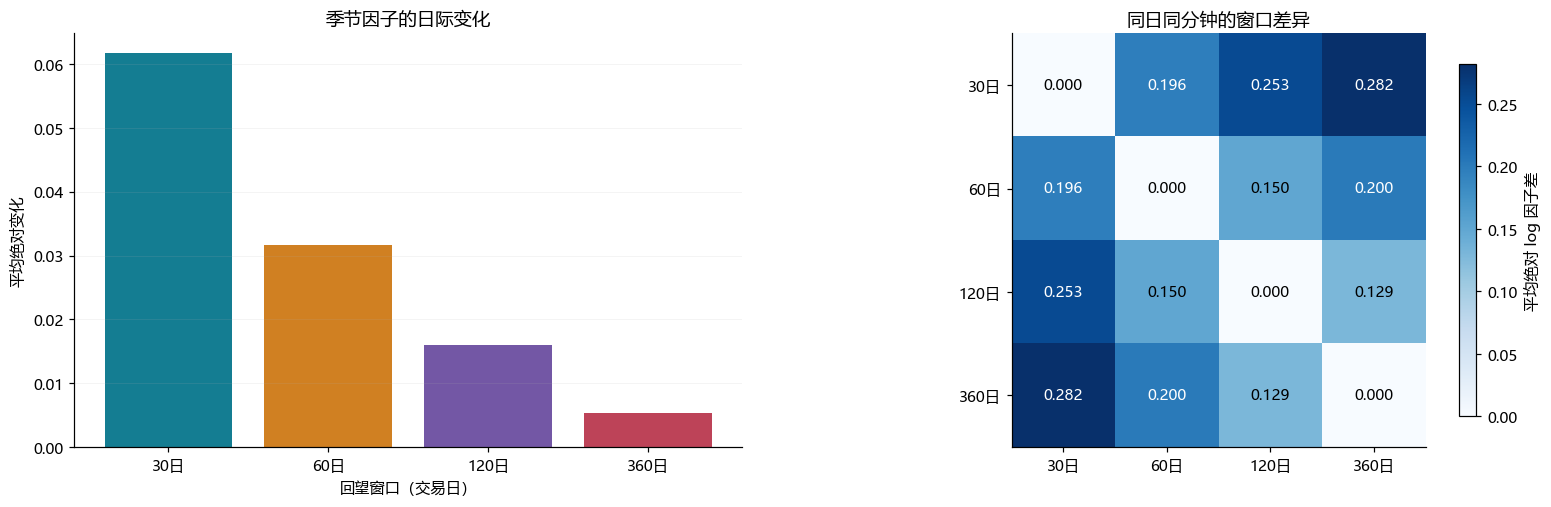

In [41]:
figure, axes = plt.subplots(
    1, 2, figsize=(14, 4.5), layout="constrained"
)

window_labels = [f"{lookback}日" for lookback in lookback_windows]
change_values = metrics_df.loc[
    [f"{lookback} 交易日" for lookback in lookback_windows],
    "因子日际平均绝对变化",
]

axes[0].bar(
    window_labels,
    change_values.to_numpy(),
    color=[window_colors[lookback] for lookback in lookback_windows],
)
axes[0].set_title("季节因子的日际变化")
axes[0].set_xlabel("回望窗口（交易日）")
axes[0].set_ylabel("平均绝对变化")
axes[0].grid(axis="y", alpha=0.18)

distance_values = window_distance_df.to_numpy()
distance_image = axes[1].imshow(
    distance_values, cmap="Blues", vmin=0
)
axes[1].set_xticks(range(len(lookback_windows)), window_labels)
axes[1].set_yticks(range(len(lookback_windows)), window_labels)
axes[1].set_title("同日同分钟的窗口差异")

for row_number in range(len(lookback_windows)):
    for column_number in range(len(lookback_windows)):
        value = distance_values[row_number, column_number]
        axes[1].text(
            column_number, row_number, f"{value:.3f}",
            ha="center", va="center",
            color="white" if value > distance_values.max() * 0.6 else "black",
        )

figure.colorbar(
    distance_image,
    ax=axes[1],
    label="平均绝对 log 因子差",
    shrink=0.85,
)

plt.show()
plt.close(figure)

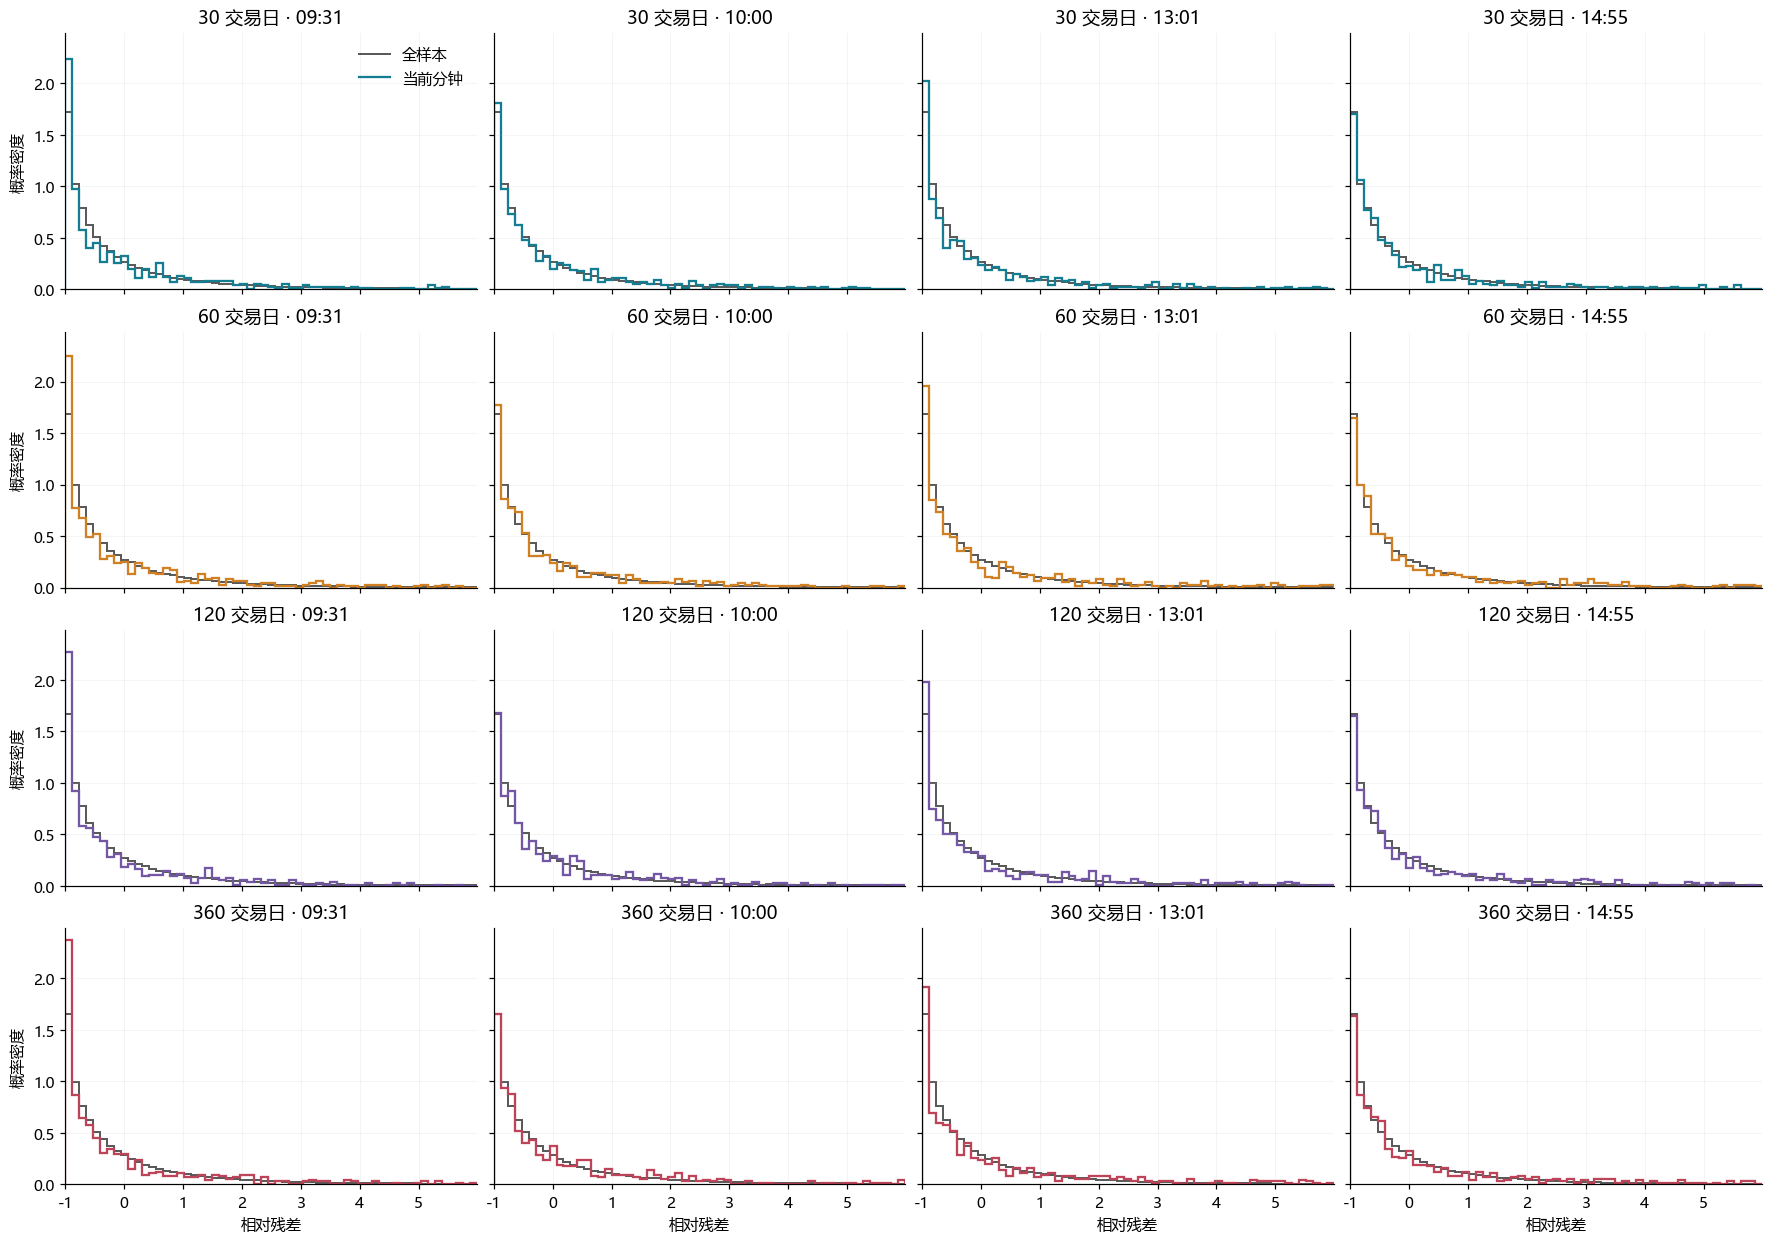

In [49]:
# 修改这里，选择需要比较的分钟
distribution_slots = [
    dt.time(9, 31),
    dt.time(10, 0),
    dt.time(13, 1),
    dt.time(14, 55),
]

# 全样本：同一回望窗口、相同日期范围内的全部分钟
# 共用分箱；展示至全样本共同 99% 分位数，密度仍按全部观测计算
minute_distribution_bins = np.linspace(-1, distribution_upper, 60)
bin_widths = np.diff(minute_distribution_bins)

figure, axes = plt.subplots(
    len(lookback_windows),
    len(distribution_slots),
    figsize=(4 * len(distribution_slots), 2.8 * len(lookback_windows)),
    sharex=True,
    sharey=True,
    squeeze=False,
    layout="constrained",
)

for row, lookback in enumerate(lookback_windows):
    full_values = distribution_by_lookback[lookback]
    full_counts, _ = np.histogram(
        full_values, bins=minute_distribution_bins
    )
    full_density = full_counts / (full_values.size * bin_widths)

    for column, minute_slot in enumerate(distribution_slots):
        axis = axes[row, column]

        minute_values = (
            residual_by_lookback[lookback]
            .loc[comparison_dates, minute_slot]
            .to_numpy()
        )
        minute_values = minute_values[np.isfinite(minute_values)]
        minute_counts, _ = np.histogram(
            minute_values, bins=minute_distribution_bins
        )
        minute_density = minute_counts / (
            minute_values.size * bin_widths
        )

        axis.stairs(
            full_density,
            minute_distribution_bins,
            color="black",
            linewidth=1.3,
            alpha=0.65,
            label="全样本",
        )
        axis.stairs(
            minute_density,
            minute_distribution_bins,
            color=window_colors[lookback],
            linewidth=1.5,
            label="当前分钟",
        )


        axis.set_title(
            f"{lookback} 交易日 · {minute_slot.strftime('%H:%M')}"
        )
        axis.set_xlim(-1, distribution_upper)
        axis.grid(alpha=0.18)

        if column == 0:
            axis.set_ylabel("概率密度")
        if row == len(lookback_windows) - 1:
            axis.set_xlabel("相对残差")

axes[0, 0].legend(frameon=False)
plt.show()
plt.close(figure)

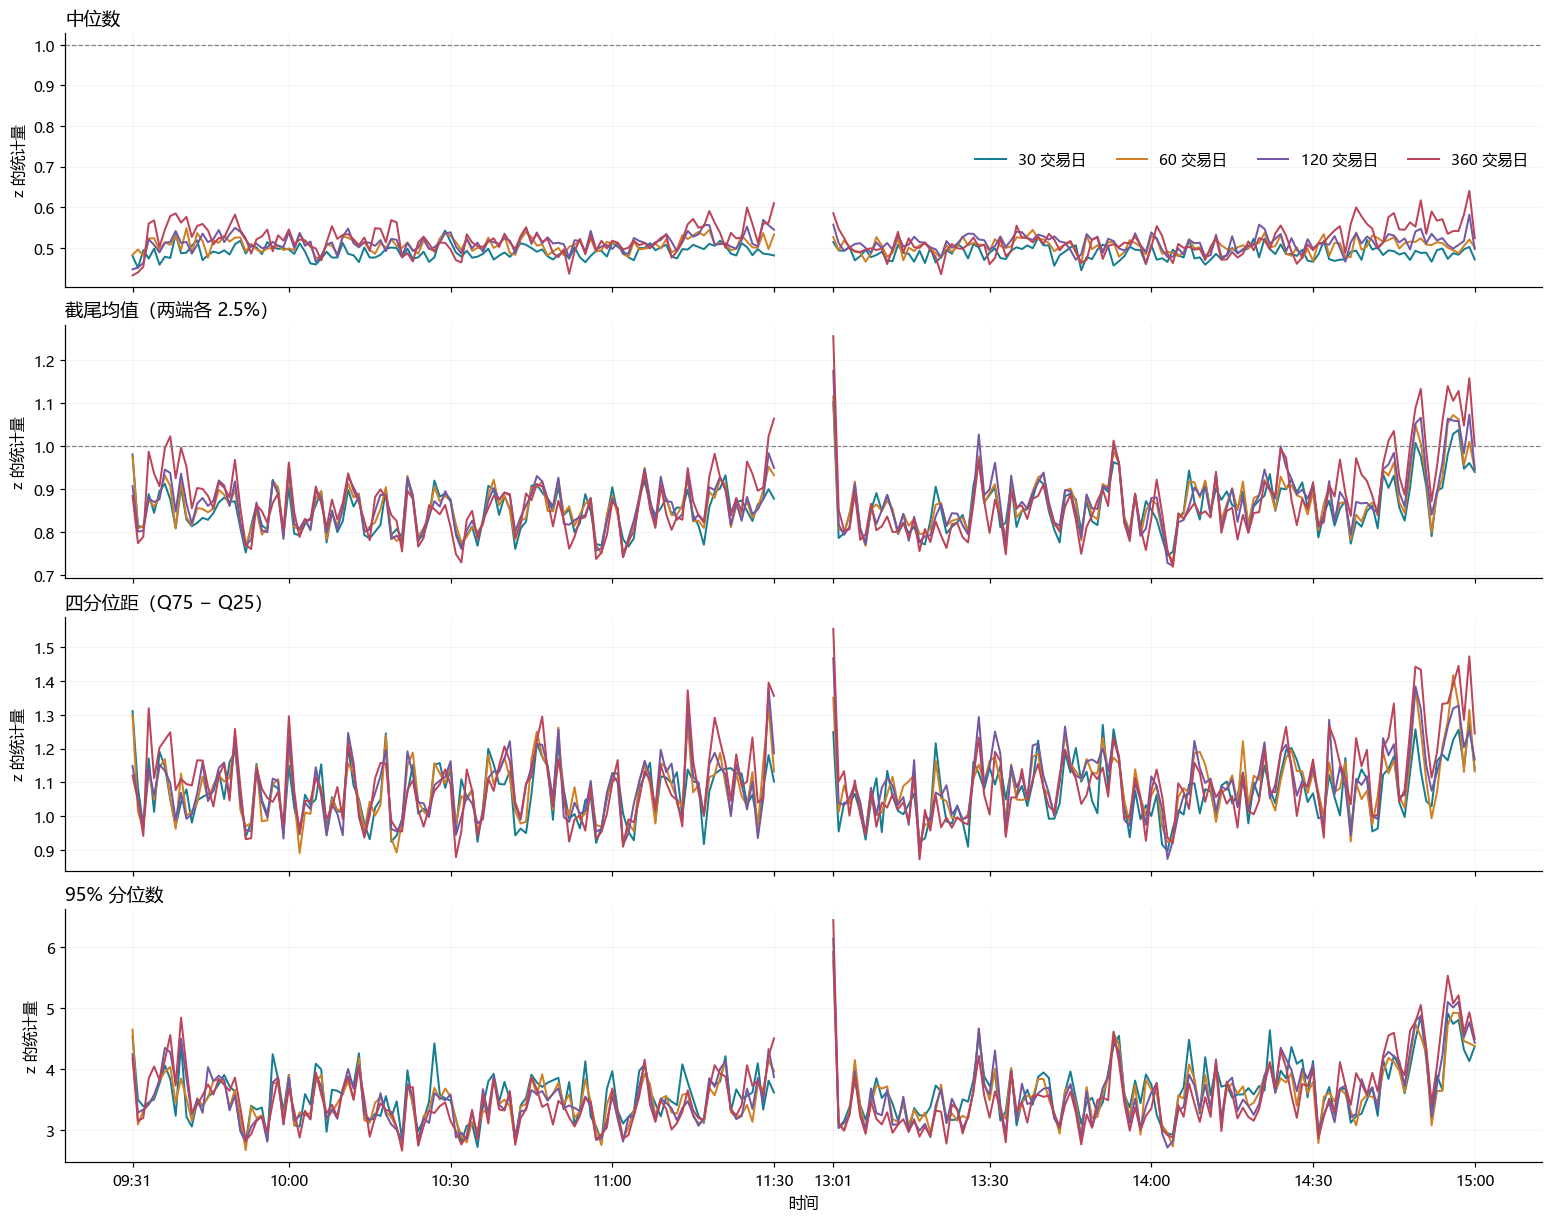

In [50]:
# 每个分钟跨日期统计；截尾均值删除两端各 2.5% 的观测
trim_fraction = 0.025
diagnostic_names = [
    "中位数",
    "截尾均值（两端各 2.5%）",
    "四分位距（Q75 − Q25）",
    "95% 分位数",
]
diagnostic_by_lookback = {}

for lookback in lookback_windows:
    # z = 去季节后的贡献 / 当日平均贡献
    z_values = (
        residual_by_lookback[lookback]
        .loc[comparison_dates, minute_slots]
        .to_numpy()
    ) + 1

    q25, median_values, q75, q95 = np.quantile(
        z_values, [0.25, 0.50, 0.75, 0.95], axis=0
    )

    sorted_values = np.sort(z_values, axis=0)
    trim_count = int(z_values.shape[0] * trim_fraction)
    trimmed_mean_values = sorted_values[
        trim_count:z_values.shape[0] - trim_count
    ].mean(axis=0)

    diagnostic_by_lookback[lookback] = [
        median_values,
        trimmed_mean_values,
        q75 - q25,
        q95,
    ]

figure, axes = plt.subplots(
    4, 1,
    figsize=(14, 11),
    sharex=True,
    layout="constrained",
)
diagnostic_positions = np.asarray(plot_minute_positions)

for metric_index, axis in enumerate(axes):
    for lookback in lookback_windows:
        profile_values = diagnostic_by_lookback[lookback][metric_index]

        for start, end in [(0, 120), (120, 240)]:
            axis.plot(
                diagnostic_positions[start:end],
                profile_values[start:end],
                color=window_colors[lookback],
                linewidth=1.3,
                label=f"{lookback} 交易日" if start == 0 else None,
            )

    if metric_index < 2:
        axis.axhline(
            1, color="gray", linestyle="--", linewidth=0.8
        )

    axis.set_title(diagnostic_names[metric_index], loc="left")
    axis.set_ylabel("z 的统计量")
    axis.grid(alpha=0.18)

axes[0].legend(ncol=4, frameon=False)

diagnostic_tick_indices = [
    0, 29, 59, 89, 119, 120, 149, 179, 209, 239
]
axes[-1].set_xticks(
    diagnostic_positions[diagnostic_tick_indices],
    [
        minute_slots[i].strftime("%H:%M")
        for i in diagnostic_tick_indices
    ],
)
axes[-1].set_xlabel("时间")

plt.show()
plt.close(figure)